# CAP4453 — Assignment 5: Autoencoders (AE) & Variational Autoencoders (VAE) — CIFAR‑10 (MSE)

In this assignment you will implement and compare an **Autoencoder (AE)** and a **Variational Autoencoder (VAE)** on **CIFAR‑10** using **MSE reconstruction loss** (in normalised space). Preprocessing is provided so you can focus on the models and training loops.

**You will (no hyper‑parameter tuning required):**
- Implement a convolutional **AE** for image reconstruction (**MSE** loss).
- Implement a **VAE** with a Gaussian latent space using the **reparameterization trick** and **KL** regularization (**MSE + β·KL**, with **β fixed**).
- Run **one training run** for AE and **one training run** for VAE using the provided settings.
- Select the **best checkpoint by validation MSE**, then evaluate **test MSE once**.
- Visualise **reconstructions** (AE & VAE) and **random samples** (VAE).

⚠️ This notebook is a minimal scaffold with `# STUDENT TODO:` markers.


## 1) Setup & Environment

In [1]:
# Minimal imports
import os, random, time
from typing import Tuple, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils

import numpy as np
import matplotlib.pyplot as plt
from math import prod

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2) Dataset & Transforms (CIFAR‑10, preprocessing ready)

**Dataset is fixed to CIFAR‑10** for this assignment.

We apply **ToTensor + Normalize** using standard CIFAR‑10 statistics. Your decoders should output tensors in the **same normalised scale** (no sigmoid/tanh required). We compute **MSE** directly between outputs and targets in normalised space.

Use the provided `denormalize(...)` helper to visualise images in the original 0–1 range.


In [2]:
# ---- CONFIG (fixed for this assignment; no tuning required) ----
BATCH_SIZE   = 128
NUM_WORKERS  = 2
VAL_RATIO    = 0.1
DATA_DIR     = './data'

# CIFAR-10 normalization statistics
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

def denormalize(x: torch.Tensor, mean, std):
    """Undo Normalize for visualisation (expects NCHW in normalised scale)."""
    m = torch.tensor(mean, device=x.device)[:, None, None]
    s = torch.tensor(std,  device=x.device)[:, None, None]
    return x * s + m

# Transforms (keep simple — focus is on reconstruction)
train_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
val_test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Datasets & loaders (CIFAR-10 only)
full_train = datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=train_tfms)
test_ds    = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=val_test_tfms)
in_channels, H, W = 3, 32, 32

val_size   = int(len(full_train) * VAL_RATIO)
train_size = len(full_train) - val_size
train_ds, val_ds = torch.utils.data.random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)} | Input shape: ({in_channels},{H},{W})')


100%|██████████| 170M/170M [00:02<00:00, 73.2MB/s] 


Train: 45000 | Val: 5000 | Test: 10000 | Input shape: (3,32,32)


## 3) Autoencoder (AE) — MSE Reconstruction

Build a **convolutional AE**:
- **Encoder**: a few Conv → ReLU → (Stride/Pool) blocks to compress to a latent vector `z`.
- **Decoder**: a mirror using ConvTranspose2d or Upsample+Conv blocks to reconstruct to `(C,H,W)`.
**No sigmoid/tanh at the end** — outputs stay in **normalised** scale. We compute **MSE** vs normalised inputs.


In [3]:
LATENT_DIM = 64   # fixed default (no tuning required)

class EncoderAE(nn.Module):
    def __init__(self, in_ch: int, latent_dim: int):
        super().__init__()
        # STUDENT TODO: define a small conv encoder. Example idea (do NOT copy blindly):
        # STUDENT TODO: define a small conv encoder. Example idea (do NOT copy blindly):
        # Conv2d(in_ch, 32, 3, stride=2, padding=1) -> ReLU -> Conv2d(32, 64, 3, stride=2, padding=1) -> ReLU -> Flatten -> Linear -> z
        self.encoder = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, latent_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # STUDENT TODO: forward pass to z
        z = self.encoder(x)
        return z

class DecoderAE(nn.Module):
    def __init__(self, out_ch: int, latent_dim: int):
        super().__init__()
        # STUDENT TODO: mirror: Linear -> reshape -> ConvTranspose2d / Upsample+Conv blocks back to (out_ch,H,W)
        self.fc = nn.Linear(latent_dim, 64 * 8 * 8)
        self.decoder= nn.Sequential(
            nn.ConvTranspose2d(64, 32,kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, out_ch, kernel_size=3, stride=2, padding=1, output_padding=1)
        )
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # STUDENT TODO: map z back to image space (normalised scale)
        x = self.fc(z)
        x = x.view(-1, 64, 8, 8)
        x_hat = self.decoder(x)
        return x_hat
class Autoencoder(nn.Module):
    def __init__(self, in_ch: int, latent_dim: int):
        super().__init__()
        self.enc = EncoderAE(in_ch, latent_dim)
        self.dec = DecoderAE(in_ch, latent_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.enc(x)
        x_hat = self.dec(z)
        return x_hat


## 4) Variational Autoencoder (VAE) — MSE + KL

Implement a VAE with a **Gaussian latent**:
- Encoder outputs **μ(x)** and **logσ²(x)**.
- **Reparameterize**: `z = μ + σ ⊙ ε`, where `ε ~ N(0, I)` and `σ = exp(0.5·logvar)`.
- **Loss** = **MSE**(x̂, x) + **β·KL**(q(z|x) || N(0, I)).
We give you **more hints** and a ready‑to‑use **KL** helper.

In [4]:
LATENT_DIM_VAE = 32   # fixed default (no tuning required) 
BETA            = 1.0  # fixed KL weight

class EncoderVAE(nn.Module):
    def __init__(self, in_ch: int, latent_dim: int):
        super().__init__()
        # STUDENT TODO: conv feature extractor -> flatten -> Linear -> outputs mu, logvar
        # Tip: output layer should have 2*latent_dim units; split as mu, logvar
        self.convs = nn.Sequential(
            nn.Conv2d(in_ch, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc = nn.Linear(64 * 8 * 8, 2 * latent_dim)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # STUDENT TODO: return mu, logvar
        x = self.convs(x)
        z = self.fc(x)

        mu, logvar = torch.chunk(z, 2, dim=1) 
        return mu, logvar
class DecoderVAE(nn.Module):
    def __init__(self, out_ch: int, latent_dim: int):
        super().__init__()
        # STUDENT TODO: map z -> feature map -> deconv/upsample -> image (normalised scale)
        self.fc = nn.Linear(latent_dim, 64 * 8 * 8)
        self.decode = nn.Sequential(nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, out_ch, kernel_size=3, stride=2, padding=1, output_padding=1))
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # STUDENT TODO: decode z to x_hat (normalised scale)
        x = self.fc(z)
        x = x.view(-1, 64, 8, 8)
        x = self.decode(x)
        return x
class VAE(nn.Module):
    def __init__(self, in_ch: int, latent_dim: int):
        super().__init__()
        self.enc = EncoderVAE(in_ch, latent_dim)
        self.dec = DecoderVAE(in_ch, latent_dim)

    @staticmethod
    def reparameterize(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """Reparameterization trick: z = mu + std * eps, std = exp(0.5 * logvar)."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # STUDENT TODO: encode -> mu, logvar; z = reparameterize(mu, logvar); decode -> x_hat
        mu, logvar = self.enc(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.dec(z)
        return x_hat, mu, logvar


## 5) Loss Functions (MSE Only) + KL Helper

- **Reconstruction:** **MSE** between **normalised** inputs and outputs.
- **KL:** analytic KL for diagonal Gaussians.


In [5]:
def reconstruction_mse(x_hat: torch.Tensor, x: torch.Tensor, reduction: str = 'mean') -> torch.Tensor:
    """MSE reconstruction loss on normalised tensors.
    reduction: 'mean' (default) averages over batch + channels + H + W; 'sum' sums over all elements.
    """
    return F.mse_loss(x_hat, x, reduction=reduction)

def kl_divergence(mu: torch.Tensor, logvar: torch.Tensor, reduction: str = 'mean') -> torch.Tensor:
    """KL(q(z|x)||N(0,I)) where q is diagonal Gaussian with given mu, logvar.
    KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar)).
    """
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # shape: (B, latent_dim)
    kl = kl.sum(dim=1)  # per-sample KL
    if reduction == 'mean':
        return kl.mean()
    elif reduction == 'sum':
        return kl.sum()
    else:
        return kl  # no reduction


## 6) Training & Evaluation Utilities

Implement the training/evaluation loops for AE and VAE using **MSE** (and **KL** for VAE).

In [6]:
def train_one_epoch_ae(model, loader, optimizer) -> float:
    model.train()
    running = 0.0
    count = 0
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_hat = model(x)
        mse = reconstruction_mse(x_hat, x)
        running += mse.item() * len(x)
        count += len(x)
        mse.backward()
        optimizer.step()
        # STUDENT TODO: forward -> x_hat; compute mse = reconstruction_mse(x_hat, x); backward; step
        # STUDENT TODO: return average loss over dataset

    return running / count
@torch.no_grad()
def evaluate_ae(model, loader) -> float:
    model.eval()
    running = 0.0
    count = 0
    for x, _ in loader:
        x = x.to(device)
        x_hat = model(x)
        mse = reconstruction_mse(x_hat, x)
        running += mse.item() * len(x)
        count += len(x)

    return running / count

def train_one_epoch_vae(model, loader, optimizer, beta: float = 1.0) -> Tuple[float, float, float]:
    model.train()
    rec_run, kl_run, elbo_run = 0.0, 0.0, 0.0
    count = 0
    for x, _ in loader:
        x = x.to(device)
        optimizer.zero_grad()
        # STUDENT TODO: x_hat, mu, logvar = model(x); rec = MSE(x_hat, x); kl = KL(mu, logvar); loss = rec + beta*kl; backward; step
        # STUDENT TODO: return averages (rec, kl, elbo)
        x_hat,mu,logvar = model(x)
        rec = reconstruction_mse(x_hat, x)
        kl = kl_divergence(mu, logvar)  
        elbo = rec + beta * kl
        elbo.backward()
        optimizer.step()
        rec_run += rec.item() * len(x)
        kl_run += kl.item() * len(x)
        elbo_run += elbo.item() * len(x)
        count += len(x)
    return rec_run / count, kl_run / count, elbo_run / count
@torch.no_grad()
def evaluate_vae(model, loader, beta: float = 1.0) -> Tuple[float, float, float]:
    model.eval()
    rec_run, kl_run, elbo_run = 0.0, 0.0, 0.0
    count = 0
    for x, _ in loader:
        x = x.to(device)
        # STUDENT TODO: x_hat, mu, logvar = model(x); rec, kl, elbo; accumulate
        x_hat,mu,logvar = model(x)
        rec = reconstruction_mse(x_hat, x)
        kl = kl_divergence(mu, logvar)
        elbo = rec + beta * kl
        rec_run += rec.item() * len(x)
        kl_run += kl.item() * len(x)
        elbo_run += elbo.item() * len(x)
        count += len(x)


        # STUDENT TODO: return averages
    return rec_run / count, kl_run / count, elbo_run / count

## 7) Experiment A — Autoencoder (AE)

**Single run workflow (no tuning required)**
1. Instantiate `Autoencoder(in_channels, LATENT_DIM)` and move to device.
2. Use the provided optimiser settings.
3. Train for `EPOCHS`; log **train/val MSE** per epoch; plot curves.
4. Save the **best checkpoint by validation MSE**, then report **best val MSE** and **test MSE**.
5. Visualise **reconstructions** (input vs output) using `denormalize`.


Epoch 01/20 | Train MSE: 0.2497 | Val MSE: 0.1512
Epoch 02/20 | Train MSE: 0.1411 | Val MSE: 0.1393
Epoch 03/20 | Train MSE: 0.1363 | Val MSE: 0.1369
Epoch 04/20 | Train MSE: 0.1342 | Val MSE: 0.1350
Epoch 05/20 | Train MSE: 0.1328 | Val MSE: 0.1340
Epoch 06/20 | Train MSE: 0.1316 | Val MSE: 0.1322
Epoch 07/20 | Train MSE: 0.1306 | Val MSE: 0.1315
Epoch 08/20 | Train MSE: 0.1296 | Val MSE: 0.1307
Epoch 09/20 | Train MSE: 0.1288 | Val MSE: 0.1305
Epoch 10/20 | Train MSE: 0.1282 | Val MSE: 0.1293
Epoch 11/20 | Train MSE: 0.1276 | Val MSE: 0.1287
Epoch 12/20 | Train MSE: 0.1271 | Val MSE: 0.1294
Epoch 13/20 | Train MSE: 0.1266 | Val MSE: 0.1282
Epoch 14/20 | Train MSE: 0.1263 | Val MSE: 0.1277
Epoch 15/20 | Train MSE: 0.1260 | Val MSE: 0.1274
Epoch 16/20 | Train MSE: 0.1256 | Val MSE: 0.1273
Epoch 17/20 | Train MSE: 0.1254 | Val MSE: 0.1273
Epoch 18/20 | Train MSE: 0.1251 | Val MSE: 0.1270
Epoch 19/20 | Train MSE: 0.1249 | Val MSE: 0.1271
Epoch 20/20 | Train MSE: 0.1245 | Val MSE: 0.1269


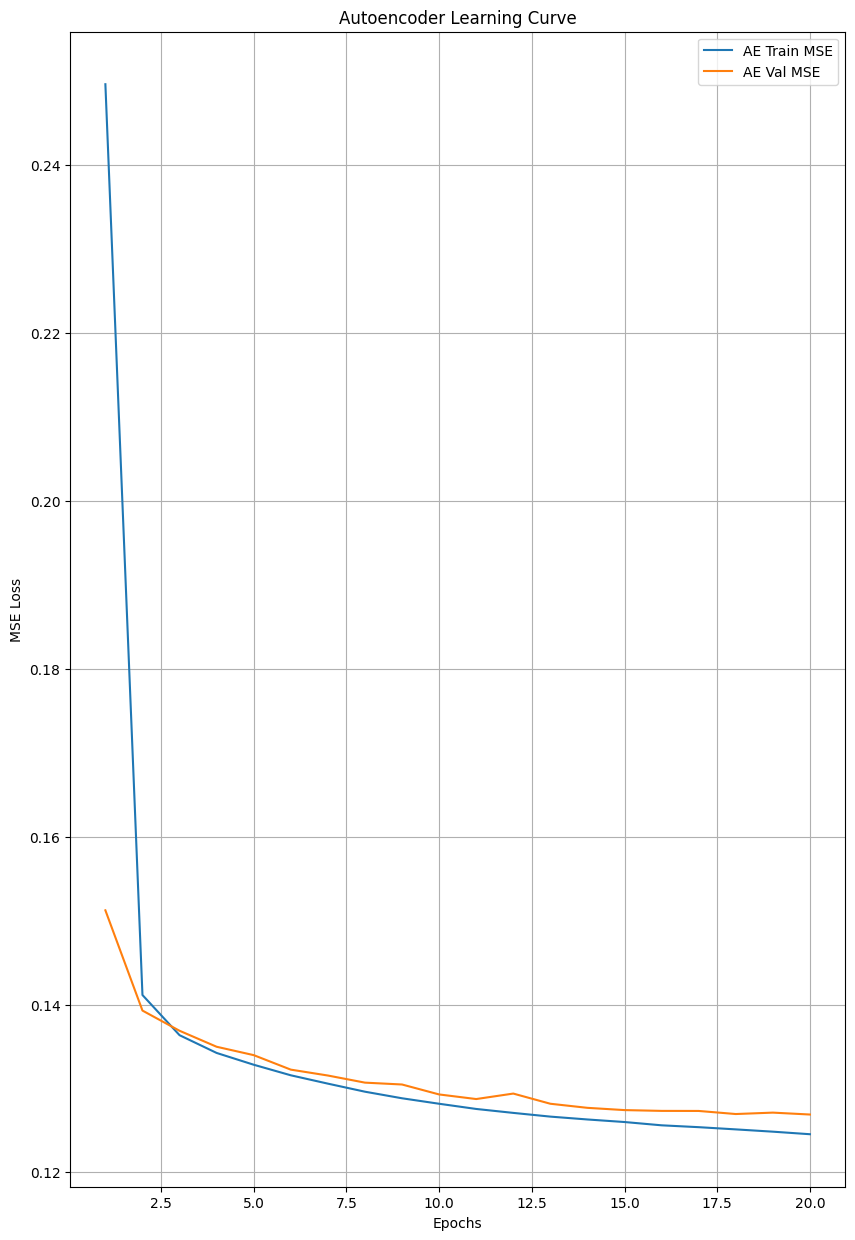

In [7]:
# Training settings (fixed defaults; no tuning required)
EPOCHS = 20
LR_AE  = 1e-3

# STUDENT TODO: instantiate AE and optimizer (use Adam with LR_AE)
ae = Autoencoder(in_channels, LATENT_DIM).to(device)
opt_ae = torch.optim.Adam(ae.parameters(), lr=LR_AE)

if ae is None or opt_ae is None:
    raise NotImplementedError('Instantiate AE and optimizer')

ae_train_hist, ae_val_hist = [], []
best_val_loss = float('inf')
# STUDENT TODO:
# - Train for EPOCHS
# - Track train/val MSE per epoch (append to histories)
# - Save best checkpoint by val MSE (e.g., torch.save(ae.state_dict(), 'ae_best.pt'))
# - Plot curves (train vs val MSE)
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_ae(ae, train_loader, opt_ae)
    val_loss = evaluate_ae(ae, val_loader)
    ae_train_hist.append(train_loss)
    ae_val_hist.append(val_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ae.state_dict(), 'best_ae_state')
plt.figure(figsize=(10,15))
plt.plot(range(1,EPOCHS + 1), ae_train_hist, label='AE Train MSE')
plt.plot(range(1,EPOCHS + 1), ae_val_hist, label='AE Val MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


## 8) Experiment B — Variational Autoencoder (VAE)

**Single run workflow (no tuning required)**
1. Instantiate `VAE(in_channels, LATENT_DIM_VAE)` and move to device.
2. Use the provided optimiser settings and fixed `BETA`.
3. Train for `EPOCHS`; log **train/val** (MSE, KL, ELBO) per epoch; plot curves.
4. Save the **best checkpoint by validation MSE**, then report **best val MSE** and **test MSE**.
5. Visualise **reconstructions** and **random samples**: draw `z ~ N(0,I)` and decode (use `denormalize` for display).


In [ ]:
# Training settings (fixed defaults; no tuning required)
LR_VAE = 1e-3

# STUDENT TODO: instantiate VAE and optimizer (use Adam with LR_VAE)
vae = VAE(in_channels, LATENT_DIM_VAE).to(device)
opt_vae = torch.optim.Adam(vae.parameters(), lr=LR_VAE)

if vae is None or opt_vae is None:
    raise NotImplementedError('Instantiate VAE and optimizer')

vae_train_hist, vae_val_hist = [], []
best_vae_val_loss = float('inf')
# STUDENT TODO:
# - Train for EPOCHS
# - Track train/val metrics per epoch: (rec MSE, KL, ELBO)
# - Save best checkpoint by validation reconstruction MSE (e.g., torch.save(vae.state_dict(), 'vae_best.pt'))
# - Plot curves (train vs val for MSE; optionally KL)
for epoch in range(1, EPOCHS + 1):
    train_mse, train_kl, train_elbo= train_one_epoch_vae(vae, train_loader, opt_vae)
    val_mse, val_kl, val_elbo = evaluate_vae(vae, val_loader)
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Rec: {train_mse:.4f} KL: {train_kl:.4f} ELBO: {train_elbo:.4f} | "
        f"Val Rec: {val_mse:.4f} KL: {val_kl:.4f} ELBO: {val_elbo:.4f}"
    )
    vae_train_hist.append(train_mse)
    vae_val_hist.append(val_mse)
    if val_mse < best_vae_val_loss:
        best_vae_val_loss = val_mse
        torch.save(vae.state_dict(), 'best_vae_state')
plt.figure(figsize=(10,15))
plt.plot(range(1,EPOCHS + 1), vae_train_hist, 'VAE Train MSE')
plt.plot(range(1, EPOCHS + 1), vae_val_hist, 'VAE Val MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Variational Autoencoder Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


Epoch 01/20 | Train Rec: 0.9926 KL: 0.0041 ELBO: 0.9967 | Val Rec: 0.9849 KL: 0.0000 ELBO: 0.9850
Epoch 02/20 | Train Rec: 0.9875 KL: 0.0001 ELBO: 0.9876 | Val Rec: 0.9848 KL: 0.0001 ELBO: 0.9849


TypeError: '<' not supported between instances of 'float' and 'tuple'

## 9) Visualisations: Reconstructions & VAE Samples

- **Reconstructions:** show a grid of input vs reconstruction for AE and VAE (use `denormalize`).
- **Random samples (VAE):** sample `z ~ N(0,I)` and decode to images (use `denormalize` for display).
- **Optional (lightweight):** print a few per-image reconstruction MSE values to compare “easy vs hard” examples.


In [ ]:
# STUDENT TODO: implement helper(s) to show reconstructions and VAE samples
# Tip: use torchvision.utils.make_grid or vutils.save_image after denormalization
raise NotImplementedError('Implement recon/sample visualisations')

## 10) Comparison & Short Analysis

In your report, include:
- **Best validation MSE** and **test MSE** for AE and VAE (from the best validation checkpoint).
- Curves: **train vs val** loss curves (AE) and **train/val MSE + KL** curves (VAE).
- Visuals: reconstructions for both models, and random samples from the VAE.
- Short discussion (a few paragraphs): reconstruction quality vs generative sampling, and common failure cases.

No hyper‑parameter search is required. Use the provided settings unless you need small changes for runtime.


In [ ]:
# STUDENT TODO: summarise results in a small table (dict / DataFrame / print)
# Include:
# - AE: best validation MSE, test MSE
# - VAE: best validation reconstruction MSE, test reconstruction MSE
raise NotImplementedError('Summarise results and print a concise table')
